# 1. Đọc dữ liệu

In [2]:
# Import các thư viện cần thiết
import os
import sys
import json 

base_dir = os.getcwd()
data_dir = os.path.join(base_dir, 'data', 'Vi-OCD')

# Đọc train/dev/test small subset data
train_data = json.load(open(os.path.join(data_dir, 'train.json'), 'r', encoding='utf-8'))
dev_data = json.load(open(os.path.join(data_dir, 'dev.json'), 'r', encoding='utf-8'))
test_data = json.load(open(os.path.join(data_dir, 'test.json'), 'r', encoding='utf-8'))

In [3]:
def summarize_split(data, name):
    print(f"{name}: {len(data):,} mẫu")

summarize_split(train_data, "Train")
summarize_split(dev_data, "Dev")
summarize_split(test_data, "Test")

print("\nSample train:")
print(train_data["0"])
print(train_data["1"])
print(train_data["2"])

Train: 4,387 mẫu
Dev: 548 mẫu
Test: 549 mẫu

Sample train:
{'review': 'gói hàng cẩn thận . chơi pubg với liên quân mượt với giá như này thì quá tốt', 'label': 'non-complaint', 'domain': 'mobile'}
{'review': 'mình góp ý thật nhé . . đừng bắt phải đăng nhập zalo nữa mình muốn tải nhạc mà không được lấy lại tôi không zalo thì gửi tin nhắn mất tiền được mã kích hoạt lại không chính xác . . mình thấy 10 ngưòi thì họ khó chịu cả 10 . . lập trình viên viết ra ứng dụng ngày càng dễ sử dụng đằng này càng ngày lại càng phức tạp và . . . bài đánh giá đầy đủ', 'label': 'complaint', 'domain': 'app'}
{'review': 'máy khá đẹp , pin trâu vân tay nhạy nhận diện khuôn mặt nhanh nói chung ổn . tuy chơi game fre fire bị chậm khung hình không mượt lắm nhưng với giá giẫm ngày 1111 được ad mã giảm giá 200k còn hơn 2tr6 thì vậy là ngon rồi', 'label'

> Khá ít, với ngôn ngữ khá đa dạng, trộn lần tiếng Việt +  tiếng Anh + từ viết tắt + sai chính tả + nhiều loại văn phong + thiếu cấu trúc. Có thể ta cần buld tokenizer vì nếu không chỉ tách theo từ có thể làm tập vocab to khổng lồ.

# 2. EDA

In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Gộp dữ liệu từ các split để EDA tổng quan
def collect_texts(data_dict):
    return [v["review"] for v in data_dict.values()]

train_texts = collect_texts(train_data)
dev_texts   = collect_texts(dev_data)
test_texts  = collect_texts(test_data)

all_texts = train_texts + dev_texts + test_texts

print(f"Tổng số câu: {len(all_texts):,}")

Tổng số câu: 5,484


In [ ]:
train_texts

In [4]:
# Phân tích unique domains và keys trong train_data
print("=== Unique Domains trong Train Data ===")
unique_domains = set()
for item in train_data.values():
    unique_domains.add(item['domain'])

print(f"Số lượng unique domains: {len(unique_domains)}")
print(f"Các domains: {sorted(unique_domains)}")

print("\n=== Unique Keys trong Train Data ===")
# Lấy keys từ một mẫu đại diện
sample_keys = set(train_data["0"].keys())
print(f"Các keys có trong mỗi sample: {sorted(sample_keys)}")

print("\n=== Phân phối Domains ===")
domain_counts = {}
for item in train_data.values():
    domain = item['domain']
    domain_counts[domain] = domain_counts.get(domain, 0) + 1

for domain, count in sorted(domain_counts.items()):
    print(f"{domain}: {count:,} samples ({count/len(train_data)*100:.1f}%)")
    
print("\n=== Phân phối Labels ===")
label_counts = {}
for item in train_data.values():
    label = item['label']
    label_counts[label] = label_counts.get(label, 0) + 1

for label, count in sorted(label_counts.items()):
    print(f"{label}: {count:,} samples ({count/len(train_data)*100:.1f}%)")

=== Unique Domains trong Train Data ===
Số lượng unique domains: 4
Các domains: ['app', 'cosmetic', 'fashion', 'mobile']

=== Unique Keys trong Train Data ===
Các keys có trong mỗi sample: ['domain', 'label', 'review']

=== Phân phối Domains ===
app: 1,613 samples (36.8%)
cosmetic: 1,043 samples (23.8%)
fashion: 1,368 samples (31.2%)
mobile: 363 samples (8.3%)

=== Phân phối Labels ===
complaint: 2,292 samples (52.2%)
non-complaint: 2,095 samples (47.8%)


## 2.1 Phân tích độ dài câu (token theo whitespace)

In [ ]:
def sentence_length_whitespace(texts):
    lengths = [len(t.strip().split()) for t in texts]
    return np.array(lengths)

train_lens = sentence_length_whitespace(train_texts)
dev_lens   = sentence_length_whitespace(dev_texts)
test_lens  = sentence_length_whitespace(test_texts)

def summarize_lengths(lengths, name):
    print(f"{name}:")
    print(f"  Min: {lengths.min()}")
    print(f"  Mean: {lengths.mean():.2f}")
    print(f"  Median: {np.median(lengths)}")
    print(f"  Max: {lengths.max()}")
    print()


In [8]:
summarize_lengths(train_lens, "Train")
summarize_lengths(dev_lens, "Dev")
summarize_lengths(test_lens, "Test")

Train:
  Min: 1
  Mean: 31.65
  Median: 20.0
  Max: 256

Dev:
  Min: 1
  Mean: 32.56
  Median: 22.0
  Max: 95

Test:
  Min: 1
  Mean: 31.90
  Median: 21.0
  Max: 293



> Có thể thấy các giá trị thống kê cơ bản không có quá nhiều khác biệt, giá trị thống kê `Max` ở dev hơi nhỏ, tuy nhiên 1 số review quá dài có thể đang chạm ngưỡng rất ít, nên ta sẽ phân tích sâu trong phần max_len

## 2.2 Phân tích phân phối độ dài để chọn `max_len`

Phần này không bắt buộc cho Transformer, nhưng hợp lý để lựa chọn max sequence length

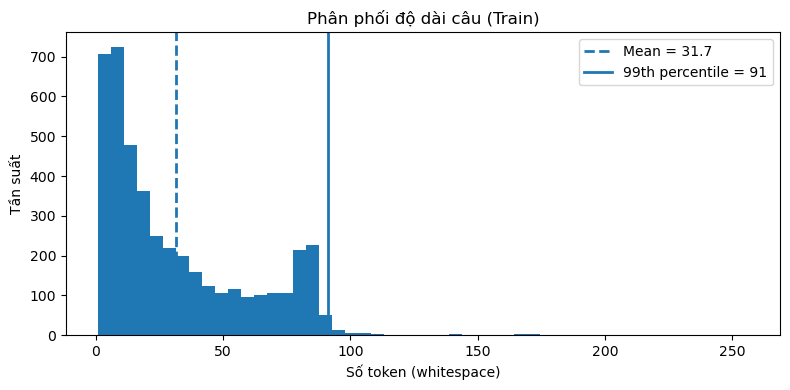

90th percentile: 80
95th percentile: 84
99th percentile: 91


In [ ]:
def plot_length_distribution(lengths, title, percentiles=(90, 95, 99)):
    mean_len = lengths.mean()
    p99 = np.percentile(lengths, 99)

    plt.figure(figsize=(8, 4))
    plt.hist(lengths, bins=50)
    
    # Mean line
    plt.axvline(
        mean_len, 
        linestyle="--", 
        linewidth=2, 
        label=f"Mean = {mean_len:.1f}"
    )
    
    # 99th percentile line
    plt.axvline(
        p99, 
        linestyle="-", 
        linewidth=2, 
        label=f"99th percentile = {int(p99)}"
    )

    plt.title(title)
    plt.xlabel("Số token (whitespace)")
    plt.ylabel("Tần suất")
    plt.legend()
    plt.tight_layout()
    plt.show()

    for p in percentiles:
        print(f"{p}th percentile: {np.percentile(lengths, p):.0f}")

plot_length_distribution(train_lens, "Phân phối độ dài câu (Train)")

Phân phối độ dài câu lệch phải mạnh, có 1 số outliers cho câu dài nhưng trong ngữ cảnh review sản phẩm thì nó là điều bình thường.

## 2.3 Phân tích tập từ điển (min_freq – mang tính tham khảo)

Phần này chỉ dùng để mô tả dữ liệu, không dùng nếu dùng pretrained tokenizer.

In [13]:
from collections import Counter

def build_vocab_whitespace(texts):
    counter = Counter()
    for t in texts:
        counter.update(t.strip().split())
    return counter

vocab_counter = build_vocab_whitespace(train_texts)

print(f"Tổng số token (train): {sum(vocab_counter.values()):,}")
print(f"Kích thước vocab (train): {len(vocab_counter):,}")

Tổng số token (train): 138,863
Kích thước vocab (train): 4,629


In [14]:
def analyze_min_freq(counter, freqs=(1, 2, 5, 10)):
    for f in freqs:
        kept = sum(1 for _, c in counter.items() if c >= f)
        print(f"min_freq ≥ {f}: vocab size = {kept:,}")

analyze_min_freq(vocab_counter)

min_freq ≥ 1: vocab size = 4,629
min_freq ≥ 2: vocab size = 2,757
min_freq ≥ 5: vocab size = 1,692
min_freq ≥ 10: vocab size = 1,191


Rất nhiều token xuất hiện 1–2 lần

=> Phản ánh: Lỗi chính tả, các biến thể (không dấu), icon,...

=> Việc cắt vocab theo min_freq không phù hợp với dữ liệu nhiễu

# 3. Kết luận

* Tập dữ liệu UIT-ViOCD gồm **5,484 câu bình luận**, với độ dài câu phân bố tương đối đồng đều giữa các tập Train, Dev và Test.
* Độ dài câu trung bình dao động quanh **32 token**, trong khi **median chỉ khoảng 20–22 token**, cho thấy phân phối lệch phải với một số câu rất dài.
* Phần lớn câu có độ dài vừa phải: **90% câu ≤ 80 token**, **95% ≤ 84 token** và **99% ≤ 91 token**, tuy vẫn tồn tại một số ngoại lệ có độ dài trên 250 token.
* Tập từ vựng huấn luyện có **4,629 token**, trong đó tỷ lệ lớn là các token tần suất thấp; khi tăng ngưỡng `min_freq`, kích thước vocab giảm nhanh.
* Các đặc điểm trên phản ánh dữ liệu có mức độ nhiễu cao (lỗi chính tả, biến thể từ, câu ngắn và dài xen kẽ), qua đó **ủng hộ việc sử dụng tokenizer pretrained và lựa chọn độ dài chuỗi đầu vào cố định (ví dụ 128)** để đảm bảo hiệu quả và ổn định khi huấn luyện Transformer Encoder.